<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Классификация звуков</b></h3>

**Автор**: Ермекова Асель


В этом задании вам предстоит решить задачу классификации звуков на основе wav файлов и использовании различных аугментаций данных.

Есть две части этого домашнего задания.

### 1 Часть. Отправить ваши предсказания в Stepik.
Результат вашей лучшей модели будет оцениваться на тестовой выборке по метрике Accuracy. Эта часть оценивается до 5 баллов.

1) $1.00 \geqslant score \geqslant 0.75$ --- 5 баллов

2) $0.75 > score \geqslant 0.70$ --- 4 балла

3) $0.70 > score \geqslant 0.60$ --- 3 балла

4) $0.60 > score \geqslant 0.50$ --- 2 балла

5) $0.50 > score \geqslant 0.25$ --- 1 балл

6) $0.25 > score$ --- 0 баллов

Для этого мы предварительно разделили данные в задании на три части.

1. `train.csv`. На этом наборе данных вам необходимо создать и обучить модель.
2. `valid.csv`. На этом наборе данных вы можете валидировать вашу модель.
3. `test.csv`. Предсказания для этого набора необходимо записать в файл `submission.csv` и сдать в соответствующий шаг на Stepik. Количество попыток ограничено до 100 штук. В конце ноутбука есть пример оформления файла посылки.

### 2 Часть. Сделать полноценный отчет о вашей работе (5 баллов).
Опишите итеративный процесс улучшения метрики:
* как вы обработали данные, какие аугментации добавляли, что сработало, а что нет.
* какие архитектуры модели попробовали и какие результаты получились.

В этом пункте вам необходимо отправить файл в формате .ipynb на Stepik --- для этого в домашнем задании есть отдельный шаг. Этот пункт оценивается до 5 баллов.

### Peer-review
Вторая часть будет проверяться в формате peer-review, т.е. вашу посылку на Stepik будут проверять 3 других студента, и медианное значение их оценок будет выставлено. Чтобы получить баллы, вам также нужно будет проверить трех других учеников. Это станет доступно после того, как вы сдадите задание сами.


### Несколько замечаний по выполнению работы
* Во всех пунктах указания это минимальный набор вещей, которые стоит сделать. Если вы можете сделать какой-то шаг лучше или добавить что-то свое --- дерзайте!
* Пожалуйста, перед сдачей ноутбука убедитесь, что работа чистая и понятная. Это значительно облегчит проверку и повысит ваши ожидаемые баллы.
* Если у вас будут проблемы с решением или хочется совета, то пишите в наш чат в телеграме.


# **Environmental Sound Classification**

## **Task Overview**

В этом домашнем задании вам предстоит работать с датасетом различных звуков окружающей среды (собака, дождь, плач ребёнка и т. д.).

### **Part 1: Create Dataset**

In [ ]:
!gdown 1TQa-tOX1b8QxuXBcrYrTveVAwfw1XBPO # sound_classification_dataset.zip
!gdown 1BvUhnTeOvik0NeuJtMrfr7LXpHCU1DUT # train.csv
!gdown 1my0RPDQdTxvCGmnZei06tiXgKko3R4o4 # valid.csv
!gdown 1Z6BG52Tmyjxhen7DqvO59Rlz-2pAg7ks # test.csv

Downloading...
From (original): https://drive.google.com/uc?id=1TQa-tOX1b8QxuXBcrYrTveVAwfw1XBPO
From (redirected): https://drive.google.com/uc?id=1TQa-tOX1b8QxuXBcrYrTveVAwfw1XBPO&confirm=t&uuid=e85323b2-f2fa-4571-916d-4c1fc8cebc80
To: /content/sound_classification_dataset.zip
100% 645M/645M [00:08<00:00, 76.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1BvUhnTeOvik0NeuJtMrfr7LXpHCU1DUT
To: /content/train.csv
100% 3.09k/3.09k [00:00<00:00, 14.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1my0RPDQdTxvCGmnZei06tiXgKko3R4o4
To: /content/valid.csv
100% 1.06k/1.06k [00:00<00:00, 4.17MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Z6BG52Tmyjxhen7DqvO59Rlz-2pAg7ks
To: /content/test.csv
100% 719/719 [00:00<00:00, 3.70MB/s]


In [ ]:
!unzip -q /content/sound_classification_dataset.zip

In [ ]:
import pandas as pd
import librosa
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio
import warnings
warnings.filterwarnings("ignore")

In [ ]:
train_df = pd.read_csv("train.csv")
valid_df = pd.read_csv("valid.csv")
test_df = pd.read_csv("test.csv")

In [ ]:
set(train_df["category"])

{'clock_tick', 'crying_baby', 'dog', 'rain', 'sneezing'}

#### Посмотрим одно из аудио

In [ ]:
train_df.sample(3)

,filename,category
116,3-171012-A-38.wav,clock_tick
96,3-150363-A-38.wav,clock_tick
49,2-118072-A-0.wav,dog


In [ ]:
import torchaudio

path = "/content/content/sound_classification_dataset/"+train_df.loc[86]["filename"]

load_example = torchaudio.load(path)

info = torchaudio.info(path)
print(info)

AudioMetaData(sample_rate=44100, num_frames=220500, num_channels=1, bits_per_sample=16, encoding=PCM_S)


In [ ]:
Audio(path) #тиканье часов

Для этого задания при создании датасета вам нужно сделать обработку аудио данных следующим образом:
* **Sample rate --> 16000**: ресэмплируйте оригинальный `sample_rate` в `sample_rate = 16000`
* **Stereo --> Mono**: преобразуйте многоканальное аудио в моноканальное
* **Length = X secs:** чтобы суметь создать батч, вам необходимо, чтобы длина всех ваших аудиозаписей была одинаковой, поэтому вам нужно зафиксировать длину всех аудиозаписей, и если аудио меньше заданной длины, то сделайте паддинг, если больше, обрежьте аудио до заданной длины.

* **Audio Augmentation:** используйте разные аугментации. Вы можете воспользоваться библиотеками:
  * [torchaudio.transforms](https://docs.pytorch.org/audio/main/transforms.html)
  * [torch_audiomentations](https://github.com/iver56/torch-audiomentations)

**ВАЖНО**: в этом домашнем задании вам нельзя переводить `wav` в мелспектрограммы.

Внизу для удобства предоставлен псевдокод, который можно заполнить необходимыми функциями, но вы можете видоизменять его как вам будет удобно.

In [ ]:
import torch
import torchaudio
from torch.utils.data import Dataset
import pandas as pd
import os
import torchaudio.functional  # We will use the full name
import torch.nn.functional as F # This is the standard convention


In [ ]:
class SimpleAudioDataset(Dataset):
    """A dataset to load, preprocess, and augment audio files."""

    # 1. Добавляем новый параметр is_test, по умолчанию False
    def __init__(self, df, do_augmentation=False, is_test=False):
        self.df = df
        self.do_augmentation = do_augmentation
        self.target_length = 16000
        self.is_test = is_test # Сохраняем флаг

        # 2. Создаем словарь классов только если это не тестовый набор
        if not self.is_test:
            self.classes = self.df['category'].unique()
            self.class_to_idx = {classname: i for i, classname in enumerate(self.classes)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):

        audio_file_path = "/content/content/sound_classification_dataset/" + self.df.loc[index]["filename"]


        signal, sample_rate = torchaudio.load(audio_file_path)
        signal = self._resample(signal, sample_rate)
        signal = self._stereo_to_mono(signal)
        # signal = self._cut_or_pad(signal)


        if self.do_augmentation:
            signal = self._augmentation(signal)

        # Проверяем, тестовый ли это набор
        if self.is_test:
            # Если тестовый, метки нет. Возвращаем сигнал и фиктивную метку (например, -1)
            # DataLoader все равно ее проигнорирует, т.к. в цикле предсказания мы пишем `for signals, _ in test_loader:`
            return signal.squeeze(0), -1
        else:
            # Если это обучающий/валидационный набор, работаем как раньше
            label_str = self.df.loc[index]["category"]
            label_idx = self.class_to_idx[label_str]
            label = torch.tensor(label_idx, dtype=torch.long)
            return signal.squeeze(0), label

    def _resample(self, signal, original_sr):
        return torchaudio.functional.resample(signal, original_sr, 16000)

    def _stereo_to_mono(self, signal):
        if signal.shape[0] > 1:
            return torch.mean(signal, dim=0, keepdim=True)
        return signal

    def _cut_or_pad(self, signal):
        num_samples = signal.shape[1]
        if num_samples > self.target_length:
            return signal[:, :self.target_length]
        elif num_samples < self.target_length:
            pad_amount = self.target_length - num_samples
            return F.pad(signal, (0, pad_amount))
        return signal

    def _augmentation(self, signal):
        return signal

In [ ]:
train_dataset = SimpleAudioDataset(train_df, do_augmentation = False)
valid_dataset = SimpleAudioDataset(valid_df, do_augmentation = False)

### **Part 2: Building a Model that Learns from Waveforms**

В этом разделе вам нужно написать архитектуру по вашему выбору, которая будет решать задачу классификации на 5 классов.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SoundClassificationModel_1(nn.Module):
    """Simple 1D CNN for raw audio classification."""

    def __init__(self, num_classes=5):
        super().__init__()
        # Сверточные блоки
        self.conv1 = nn.Conv1d(1, 8, kernel_size=9, stride=2, padding=4)
        self.bn1 = nn.BatchNorm1d(8)

        self.conv2 = nn.Conv1d(8, 16, kernel_size=9, stride=2, padding=4)
        self.bn2 = nn.BatchNorm1d(16)

        self.conv3 = nn.Conv1d(16, 32, kernel_size=9, stride=2, padding=4)
        self.bn3 = nn.BatchNorm1d(32)

        # Адаптивное усреднение по времени
        self.pool = nn.AdaptiveAvgPool1d(1)  # всегда возвращает (batch, channels, 1)
        self.dropout = nn.Dropout(0.3)

        # Полносвязный слой
        self.fc = nn.Linear(32, num_classes)

    def forward(self, x):
        # Если вход (batch, time), добавляем канал
        if x.ndim == 2:
            x = x.unsqueeze(1)  # (batch, 1, time)

        # Сверточные блоки с ReLU и BatchNorm
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))

        # Адаптивное усреднение по времени
        x = self.pool(x)       # (batch, channels, 1)
        x = x.squeeze(-1)      # (batch, channels)

        x = self.dropout(x)
        x = self.fc(x)         # (batch, num_classes)
        return x


In [51]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SoundClassificationMLP(nn.Module):
    """MLP для классификации звука на основе сырых сигналов."""

    def __init__(self, input_size=16000, num_classes=5, hidden_sizes=[512, 256, 128]):
        """
        input_size: длина входного аудиосигнала после downsampling/crop
        hidden_sizes: список скрытых слоёв
        """
        super().__init__()
        layers = []
        in_features = input_size

        for h in hidden_sizes:
            layers.append(nn.Linear(in_features, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.3))
            in_features = h

        layers.append(nn.Linear(in_features, num_classes))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        # если вход (batch, time)
        if x.ndim == 2:
            x = x  # (batch, time)
        elif x.ndim == 3:
            x = x.squeeze(1)  # (batch, time)

        # Flatten уже не нужен, x = (batch, time)
        return self.model(x)


In [66]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SoundClassificationModel_3(nn.Module):

    def __init__(self, num_classes=5):
        super().__init__()

        self.conv1 = nn.Conv1d(1, 16, kernel_size=9, stride=2, padding=4)
        self.bn1 = nn.BatchNorm1d(16)

        self.conv2 = nn.Conv1d(16, 32, kernel_size=7, stride=2, padding=3)  # уменьшил ядро
        self.bn2 = nn.BatchNorm1d(32)

        self.conv3 = nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2)  # уменьшил ядро
        self.bn3 = nn.BatchNorm1d(64)

        self.conv4 = nn.Conv1d(64, 64, kernel_size=3, stride=1, padding=1)
        self.bn4 = nn.BatchNorm1d(64)

        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.max_pool = nn.AdaptiveMaxPool1d(1)

        self.dropout1 = nn.Dropout(0.3)
        self.dropout2 = nn.Dropout(0.2)

        self.fc1 = nn.Linear(128, 64)  # 64 * 2 = 128 (avg + max)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        if x.ndim == 2:
            x = x.unsqueeze(1)

        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))

        x_avg = self.avg_pool(x).squeeze(-1)
        x_max = self.max_pool(x).squeeze(-1)
        x = torch.cat([x_avg, x_max], dim=1)

        x = self.dropout1(x)
        x = F.relu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc2(x)

        return x

### **Part 3: Training and Evaluation**

В этом разделе вам нужно написать код тренировки и запустить саму тренировку и вывести лучшие значения метрики качества на train и valid данных. Для вашего удобства написана функция отображения значений лоссов и метрики accuracy.

In [ ]:
def plot_metrics(train_losses, train_accuracies, test_losses, test_accuracies):
    """
    Plot training and validation metrics
    """
    epochs = range(1, len(train_losses) + 1)

    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot loss
    ax1.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)
    ax1.plot(epochs, test_losses, 'r-', label='Test Loss', linewidth=2)
    ax1.set_title('Training and Test Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot accuracy
    ax2.plot(epochs, train_accuracies, 'b-', label='Training Accuracy', linewidth=2)
    ax2.plot(epochs, test_accuracies, 'r-', label='Valid Accuracy', linewidth=2)
    ax2.set_title('Training and Valid Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Adjust layout and display
    plt.tight_layout()
    plt.show()


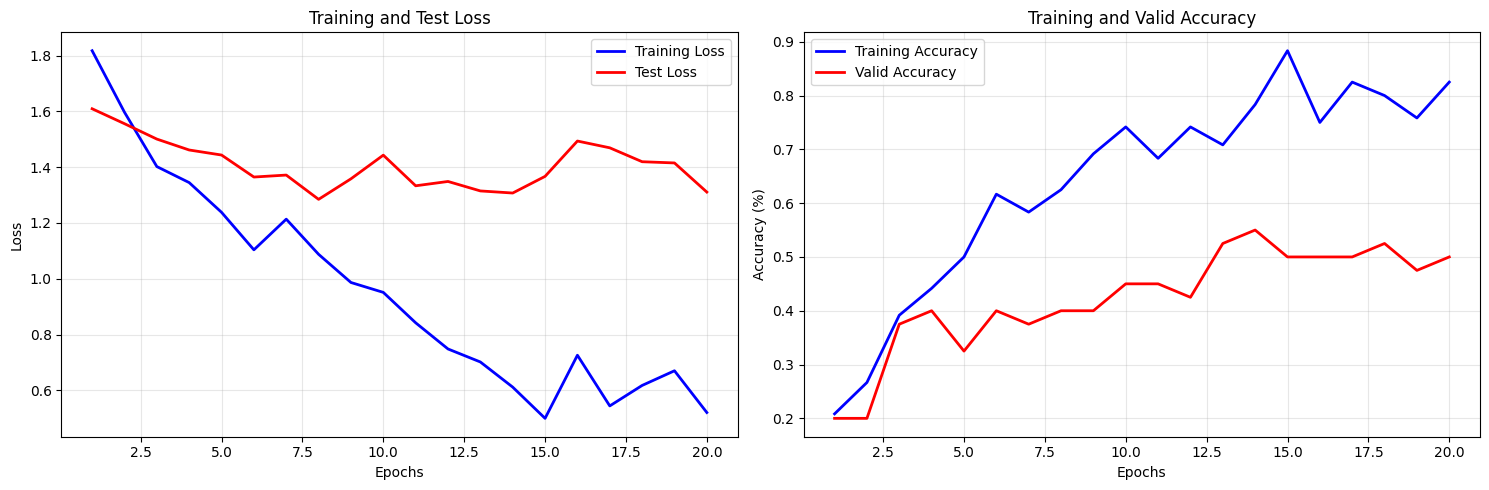

In [68]:
from torch.utils.data import DataLoader
from IPython.display import clear_output


# Initialize datasets & dataloaders
train_data = train_dataset
valid_data = valid_dataset

BATCH_SIZE = 8

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=BATCH_SIZE, shuffle=False)
# test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


# Model, Loss, Optimizer
device = "cuda" if torch.cuda.is_available() else "cpu"
# model = ImprovedSoundModel().to(device)
# model = SoundClassificationModel_1().to(device)
# model = SoundClassificationMLP()
# model = SoundClassificationMLP(input_size=80000, num_classes=5).to(device)

model = SoundClassificationModel_3().to(device)



criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


train_losses = []
train_accuracies = []
valid_losses = []
valid_accuracies = []

n_epochs = 20 # here is your code
for epoch in range(n_epochs):

    # Train
    model.train()

    running_train_loss = 0.0
    running_train_accuracy = 0.0

    for signals, labels in train_loader:

        # load data to device
        signals, labels = signals.to(device), labels.to(device)

        # Forward pass
        predictions = model(signals)
        train_loss = criterion(predictions, labels)
        # train_accuracy = # here is your code

         # Calculate accuracy for the batch
        # Find the index of the max logit (the predicted class)
        predicted_classes = predictions.argmax(dim=1)
        # Compare with true labels and calculate the mean accuracy
        train_accuracy = (predicted_classes == labels).float().mean().item()

        # Accumulate metrics
        running_train_loss += train_loss.item()
        running_train_accuracy += train_accuracy

        # Backward pass
        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

    # Evaluation
    model.eval()

    running_valid_loss = 0.0
    running_valid_accuracy = 0.0

    with torch.no_grad():
        for signals, labels in valid_loader:
            # load data to device
            signals, labels = signals.to(device), labels.to(device)

            # Forward pass
            predictions = model(signals)
            valid_loss = criterion(predictions, labels)

            # Calculate accuracy for the batch
            predicted_classes = predictions.argmax(dim=1)
            valid_accuracy = (predicted_classes == labels).float().mean().item()

            # Accumulate metrics
            running_valid_loss += valid_loss.item()
            running_valid_accuracy += valid_accuracy

    # Calculate average test loss and accuracy for this epoch
    epoch_train_loss = running_train_loss / len(train_loader)
    epoch_train_acc = running_train_accuracy / len(train_loader)

    epoch_valid_loss = running_valid_loss / len(valid_loader)
    epoch_valid_acc = running_valid_accuracy / len(valid_loader)

    # Store metrics
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)
    valid_losses.append(epoch_valid_loss)
    valid_accuracies.append(epoch_valid_acc)

    plot_metrics(train_losses, train_accuracies, valid_losses, valid_accuracies)
    clear_output(wait=True)

In [70]:
print("Train Accuracy = ", f"{epoch_train_acc*100:.2f}%")
print("Valid Accuracy = ", f"{epoch_valid_acc*100:.2f}%")


Train Accuracy =  82.50%
Valid Accuracy =  50.00%


### **Part 4. Test Demo for ESC-50**

Для вашего удобства предоставляется код для тестирования модели и отрисовки формы сигналов, прогноза и топ-5 наиболее вероятных классов.

Using device: cuda
ESC-50 Audio Classification Demo!


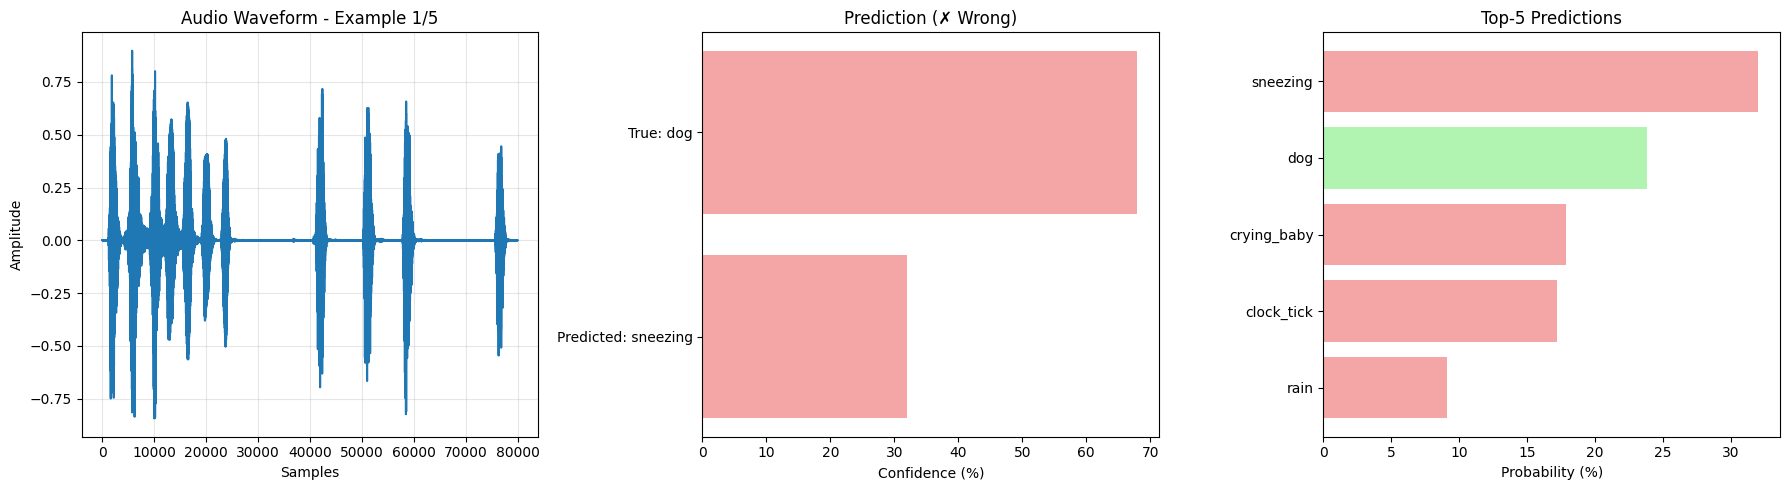

Playing: dog


Prediction: sneezing (32.01%)
True label: dog
Correct: False


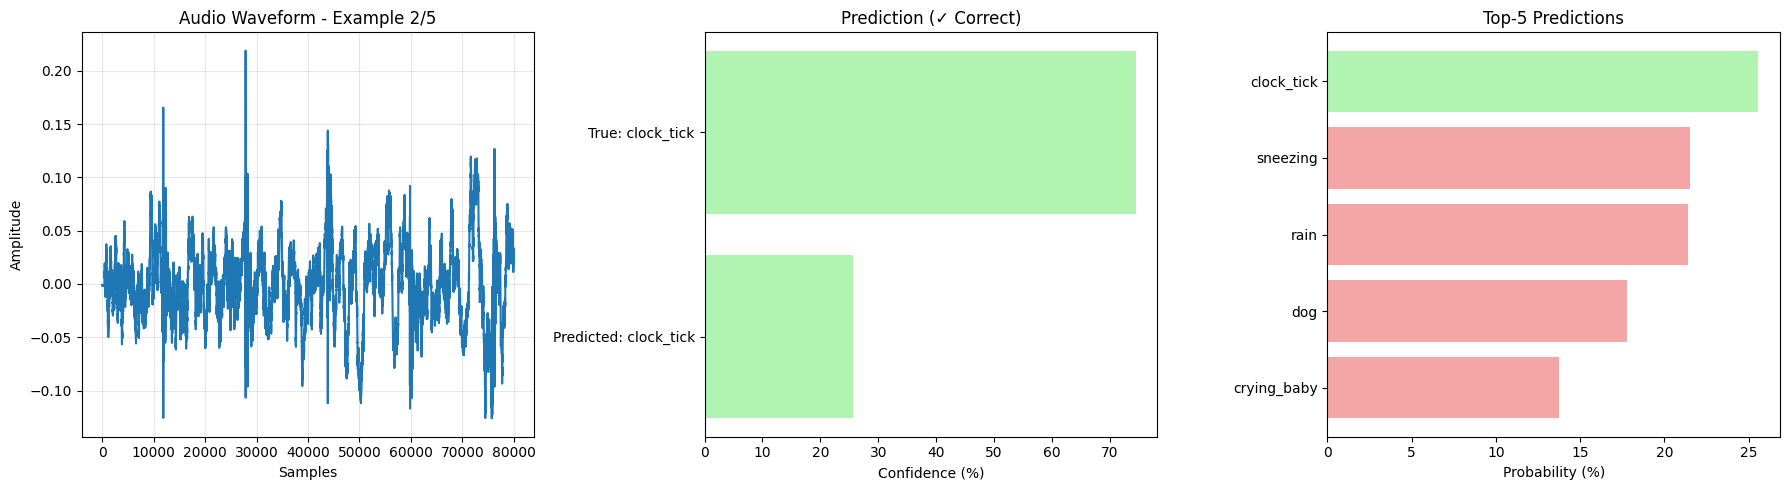

Playing: clock_tick


Prediction: clock_tick (25.58%)
True label: clock_tick
Correct: True


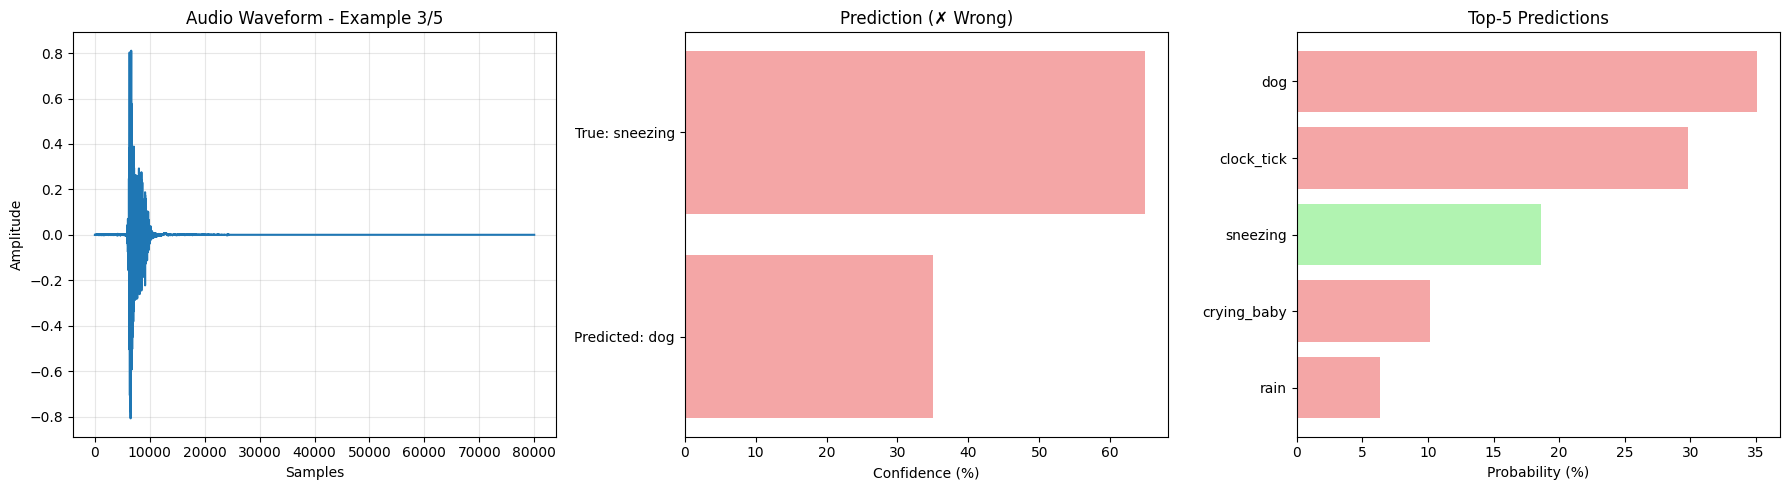

Playing: sneezing


Prediction: dog (35.08%)
True label: sneezing
Correct: False


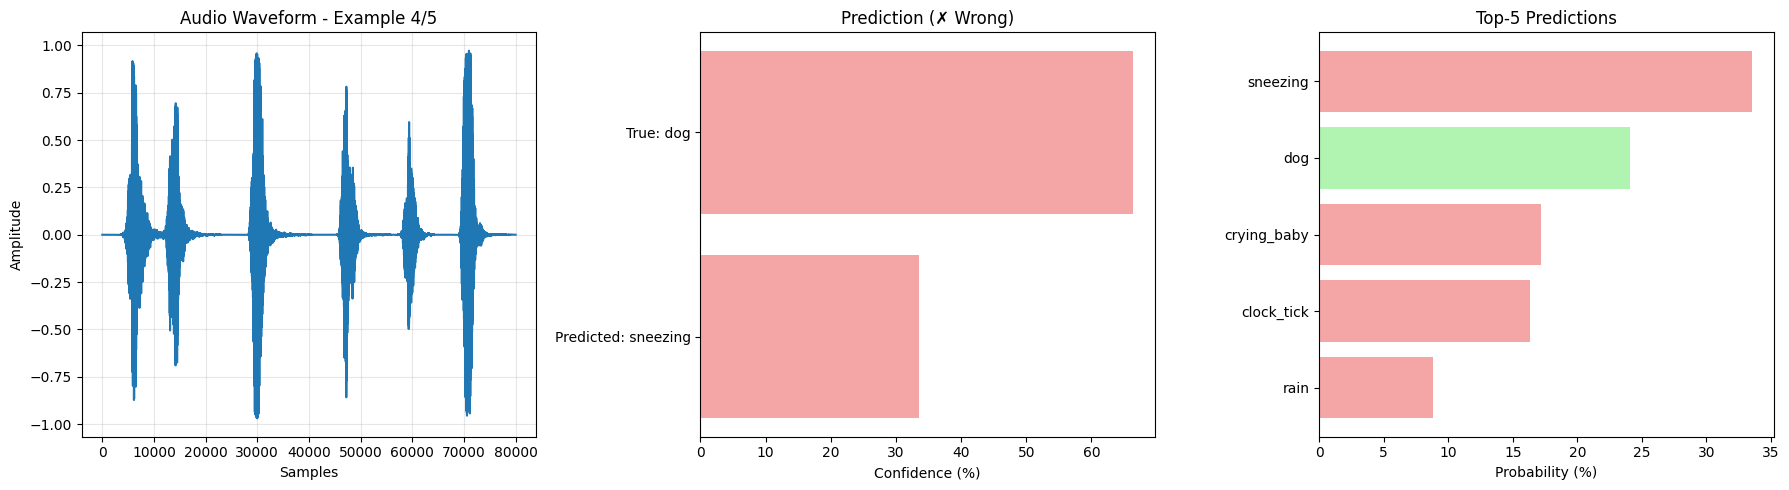

Playing: dog


Prediction: sneezing (33.54%)
True label: dog
Correct: False


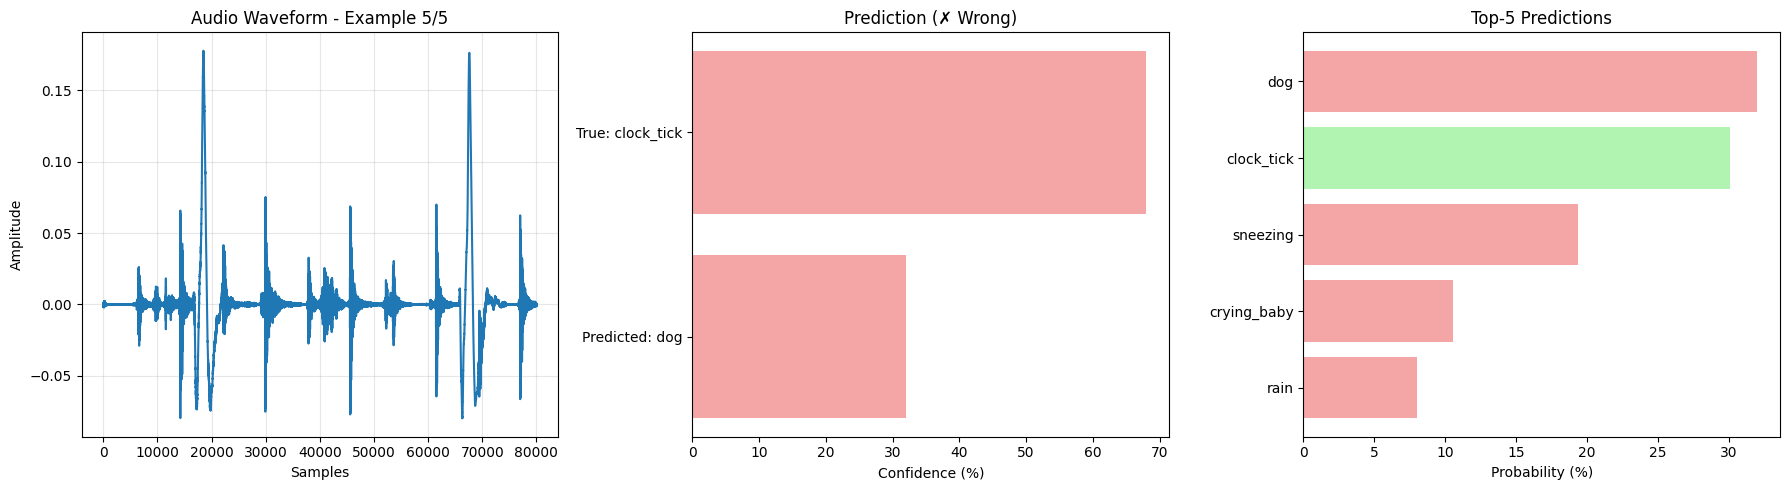

Playing: clock_tick


Prediction: dog (31.99%)
True label: clock_tick
Correct: False
ESC-50 Test Set Evaluation (Fold 5):
Correct: 15/40
Accuracy: 37.50%


In [ ]:
class ESC50TestDemo:
    def __init__(self, model, test_dataset, device):
        self.model = model
        self.test_dataset = test_dataset
        self.device = device
        self.classes = test_dataset.classes
        self.model.eval()  # Set to evaluation mode

    def predict_audio(self, signal):
        """Predict class for a single audio signal"""
        with torch.no_grad():
            signal = signal.unsqueeze(0).to(self.device)  # Add batch dimension
            outputs = self.model(signal)
            probabilities = torch.softmax(outputs, dim=1)
            confidence, predicted = torch.max(probabilities, 1)

        return predicted.item(), confidence.item(), probabilities.cpu().numpy()[0]

    def run_interactive_demo(self, num_examples=1):
        """Run interactive demo with random test examples"""
        print("ESC-50 Audio Classification Demo!")
        print("=" * 60)

        # Get random test examples
        indices = np.random.choice(len(self.test_dataset), num_examples, replace=False)

        for i, idx in enumerate(indices):
            # Load audio and true label
            signal, true_label = self.test_dataset[idx]
            true_class = self.classes[true_label]

            # Get prediction
            predicted_idx, confidence, all_probs = self.predict_audio(signal)
            predicted_class = self.classes[predicted_idx]

            # Clear previous output
            # clear_output(wait=True)

            # Create plot
            fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

            # Plot waveform
            ax1.plot(signal.squeeze().numpy())
            ax1.set_title(f'Audio Waveform - Example {i+1}/{num_examples}')
            ax1.set_xlabel('Samples')
            ax1.set_ylabel('Amplitude')
            ax1.grid(True, alpha=0.3)

            # Plot prediction info
            colors = ['lightcoral', 'lightgreen']
            correct = predicted_class == true_class
            ax2.barh([0, 1], [confidence * 100, (1-confidence) * 100],
                     color=colors[correct], alpha=0.7)
            ax2.set_yticks([0, 1])
            ax2.set_yticklabels([f'Predicted: {predicted_class}',
                               f'True: {true_class}'])
            ax2.set_xlabel('Confidence (%)')
            ax2.set_title(f'Prediction ({"✓ Correct" if correct else "✗ Wrong"})')

            # Plot top-5 predictions
            top5_indices = np.argsort(all_probs)[-5:][::-1]
            top5_classes = [self.classes[idx] for idx in top5_indices]
            top5_probs = all_probs[top5_indices]

            colors = ['lightgreen' if cls == true_class else 'lightcoral' for cls in top5_classes]
            ax3.barh(range(5), top5_probs * 100, color=colors, alpha=0.7)
            ax3.set_yticks(range(5))
            ax3.set_yticklabels(top5_classes)
            ax3.set_xlabel('Probability (%)')
            ax3.set_title('Top-5 Predictions')
            ax3.invert_yaxis()  # Highest probability at top

            plt.tight_layout()
            plt.show()

            # Display audio player
            print(f"Playing: {true_class}")
            display(Audio(signal.squeeze().numpy(), rate=16000))

            print(f"Prediction: {predicted_class} ({confidence:.2%})")
            print(f"True label: {true_class}")
            print(f"Correct: {correct}")
            print("=" * 60)


    def evaluate_test_set(self):
        """Evaluate on entire test set"""
        test_loader = DataLoader(self.test_dataset, batch_size=32, shuffle=False)
        self.model.eval()
        correct = 0
        total = 0
        all_predictions = []
        all_labels = []

        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(self.device), target.to(self.device)
                outputs = self.model(data)
                _, predicted = torch.max(outputs.data, 1)

                total += target.size(0)
                correct += (predicted == target).sum().item()

                all_predictions.extend(predicted.cpu().numpy())
                all_labels.extend(target.cpu().numpy())

        accuracy = 100 * correct / total
        print(f"ESC-50 Test Set Evaluation (Fold 5):")
        print(f"Correct: {correct}/{total}")
        print(f"Accuracy: {accuracy:.2f}%")

        return accuracy, all_predictions, all_labels

# Usage
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Create demo
demo = ESC50TestDemo(model, valid_dataset, device)

# Run interactive demo
demo.run_interactive_demo(num_examples=5)

# Evaluate on entire test set
test_accuracy, predictions, true_labels = demo.evaluate_test_set()

### **Create submission to Stepik**

Вам нужно:
* **1 шаг.** сделать предсказания для `test.csv` при помощи лучшей модели
* **2 шаг.** создать `submission.csv` файл с колонкой `category`, положить туда свои предсказания и сохранить файл.

In [75]:
test_dataset = SimpleAudioDataset(test_df, is_test=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

model.eval()
all_predictions = []

with torch.no_grad():
    for signals, _ in test_loader:
        signals = signals.to(device)
        predictions_logits = model(signals)
        predicted_classes = torch.argmax(predictions_logits, dim=1)
        all_predictions.extend(predicted_classes.cpu().numpy())

y_test_pred = torch.tensor(all_predictions)


In [ ]:
# y_test_pred = # here are your predictions

In [76]:
label_dict = {'dog': 0, 'rain': 1, 'crying_baby': 2, 'clock_tick': 3, 'sneezing': 4}
reverse_label_dict = {v: k for k, v in label_dict.items()}

test_dataset = SimpleAudioDataset(test_df, is_test=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

model.eval()
all_predictions = []

with torch.no_grad():
    for signals, _ in test_loader:
        signals = signals.to(device)
        predictions_logits = model(signals)
        predicted_classes = torch.argmax(predictions_logits, dim=1)
        all_predictions.extend(predicted_classes.cpu().numpy())

submission = pd.read_csv("/content/test.csv")
submission['category'] = [reverse_label_dict[pred] for pred in all_predictions]
submission.to_csv("/content/submission.csv", index=False)

print("submission создан")

Submission создан!


In [ ]:
submission

,filename,category
0,5-151085-A-20.wav,crying_baby
1,5-181766-A-10.wav,rain
2,5-187979-A-21.wav,clock_tick
3,5-188655-A-10.wav,rain
4,5-193339-A-10.wav,rain
5,5-194533-A-21.wav,clock_tick
6,5-194892-A-10.wav,rain
7,5-195710-A-10.wav,rain
8,5-198321-A-10.wav,rain
9,5-198411-A-20.wav,crying_baby


In [ ]:
import torchaudio

path = "/content/content/sound_classification_dataset/"+test_df.loc[38]["filename"]

load_example = torchaudio.load(path)

info = torchaudio.info(path)
print(info)
Audio(path)

### **Report**

Опишите ваш путь экспериментов и что вы сделали, чтобы получить наилучшую модель: попробовал три разных модели, в основном эскпериментировал с первой и изменял у неё различные гиперпараметры(размер батча и эпохи). Удалось на ней выбить скор 0.775, после чего сделал чисто линейную модель ради интереса. Она сильное переобучилась и я переключился на третью. Третья модель никакого прироста не дала

Мои модели

**1. SoundClassificationModel_1**

Вход: моно-аудио (batch, time)
Слои:
- 3 × Conv1d → BatchNorm → ReLU
- AdaptiveAvgPool1d по времени
- Dropout
- Linear → выход (batch, num_classes)

Результат:
- при обучении по 16 батчам и 10 эпохам
    - Train Accuracy =  67.97%
    - Valid Accuracy =  33.33%
    -  cкор в степике 0.65
- при обучении по 32 батчам и 10 эпохам
    - Train Accuracy =  61.98%
    - Valid Accuracy =  34.38%
- при обучении по 32 батчам и 20 эпохам
    - Train Accuracy =  60.68%
    - Valid Accuracy =  31.25%
- при обучении по 8 батчам и 20 эпохам
    - Train Accuracy =  65.83%
    - Valid Accuracy =  52.50%
    - На степике: Accuracy вашего решения равен 0.775.


![Ура, победа!](https://imgs.search.brave.com/X1_e8Lyv4sJaVRtSonuLn21P5Cd1OEdVf4753VNYnAw/rs:fit:860:0:0:0/g:ce/aHR0cHM6Ly9pLnBp/bmltZy5jb20vb3Jp/Z2luYWxzL2ZjLzRi/LzBmL2ZjNGIwZmIx/ZTVkODU4ZWUwYTY5/ZmQ1YzA5ZmIxZDY1/LmpwZw)

**2. Модель из чисто линейных слоёв**
- при обучении по 8 батчам и 20 эпохам
    - Train Accuracy =  100.00%
    - Valid Accuracy =  37.50%
    - на степике accuracy 0.4
    - наверное немного переобучилась)))

**3. SoundClassificationModel_3**

- Вход: моно-аудио (batch, time)
- Слои:
    - Conv1-4 + BatchNorm + ReLU — извлечение признаков разной степени абстракции.
    - Adaptive Avg & Max Pooling — усреднение и выделение сильных активаций по времени.
    - Dropout + FC — уменьшение переобучения и классификация на num_classes категорий.
- при обучении по 8 батчам и 20 эпохам
    - Train Accuracy =  82.50%
    - Valid Accuracy =  50.00%
    - на степике: Accuracy вашего решения равен 0.775.

